In [1]:
# Install Transformers and Accelerate libraries
!pip install transformers accelerate scipy matplotlib seaborn

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np

# 1. Download a clean model from Hugging Face
model_name = "gpt2"
model = AutoModelForCausalLM.from_pretrained(model_name)

# 2. Extract weight tensors from a specific layer (e.g., an attention projection layer)
# We will focus on one layer to establish our statistical baseline
clean_weights = model.transformer.h[0].attn.c_attn.weight.detach().cpu().numpy().flatten()

print(f"Extracted {len(clean_weights)} weight parameters.")
print(f"Mean: {np.mean(clean_weights):.6f}, Std Dev: {np.std(clean_weights):.6f}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Extracted 1769472 weight parameters.
Mean: 0.000053, Std Dev: 0.199620


In [3]:
# Create a copy of the clean weights to tamper with
tampered_weights = clean_weights.copy()

# Scenario A: Direct Weight Injection (simulating a hidden payload or backdoor)
# We choose a small, localized block of weights and corrupt them
tamper_size = int(len(tampered_weights) * 0.02)  # Tamper 2% of weights
start_idx = np.random.randint(0, len(tampered_weights) - tamper_size)

# Injecting anomalous values (e.g., pulling them out of their natural normal distribution)
tampered_weights[start_idx : start_idx + tamper_size] += np.random.normal(loc=0.5, scale=0.2, size=tamper_size)

print(f"Tampered Mean: {np.mean(tampered_weights):.6f}, Tampered Std Dev: {np.std(tampered_weights):.6f}")

Tampered Mean: 0.010048, Tampered Std Dev: 0.213448


In [4]:
from sklearn.mixture import BayesianGaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape data for the model
X_clean = clean_weights.reshape(-1, 1)
X_tampered = tampered_weights.reshape(-1, 1)

# Initialize a Bayesian Gaussian Mixture Model
# It uses a Dirichlet process prior to automatically find if unexpected clusters exist
bgmm = BayesianGaussianMixture(n_components=5, weight_concentration_prior=1e-3, random_state=42)

# Fit on the suspect model weights (Simulating your zero-knowledge detector)
bgmm.fit(X_tampered)
labels = bgmm.predict(X_tampered)
scores = bgmm.score_samples(X_tampered) # Log-likelihood of each weight parameter

# Anomaly threshold: Weights with very low log-likelihood under the Bayesian mixture model
threshold = np.percentile(scores, 1)  # Flag the bottom 1% lowest probability density
anomalies = np.where(scores < threshold)[0]

print(f"Detector flagged {len(anomalies)} parameters as statistically anomalous.")

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Detector flagged 17695 parameters as statistically anomalous.


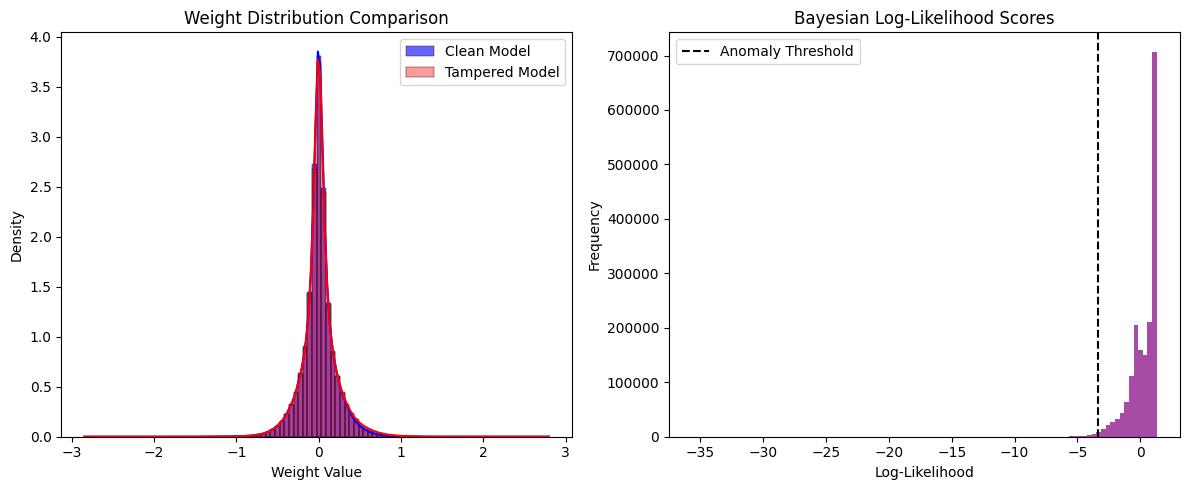

In [5]:
plt.figure(figsize=(12, 5))

# Plot clean vs tampered distribution histograms
plt.subplot(1, 2, 1)
sns.histplot(clean_weights, color="blue", label="Clean Model", kde=True, bins=100, stat="density", alpha=0.6)
sns.histplot(tampered_weights, color="red", label="Tampered Model", kde=True, bins=100, stat="density", alpha=0.4)
plt.title("Weight Distribution Comparison")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend()

# Plot the anomaly detection scores on the tampered model
plt.subplot(1, 2, 2)
plt.hist(scores, bins=100, color='purple', alpha=0.7)
plt.axvline(threshold, color='black', linestyle='--', label='Anomaly Threshold')
plt.title("Bayesian Log-Likelihood Scores")
plt.xlabel("Log-Likelihood")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
# Create ground truth labels (0 for clean weights, 1 for tampered weights)
ground_truth = np.zeros(len(clean_weights))
# Mark the specific slice we injected with noise in Step 3 as '1' (Tampered)
ground_truth[start_idx : start_idx + tamper_size] = 1

# Create binary predictions from your detector
# 1 if flagged as an anomaly, 0 if considered normal
predictions = np.zeros(len(clean_weights))
predictions[anomalies] = 1

# Calculate True Positives, False Positives, True Negatives, False Negatives
TP = np.sum((predictions == 1) & (ground_truth == 1))
FP = np.sum((predictions == 1) & (ground_truth == 0))
TN = np.sum((predictions == 0) & (ground_truth == 0))
FN = np.sum((predictions == 0) & (ground_truth == 1))

# Compute core academic metrics
tpr = TP / (TP + FN) if (TP + FN) > 0 else 0  # True Positive Rate (Detection Rate)
fpr = FP / (FP + TN) if (FP + TN) > 0 else 0  # False Positive Rate (False Alarms)

print(f"--- DETECTOR PERFORMANCE REPORT ---")
print(f"Vulnerabilities Successfully Detected (TPR): {tpr * 100:.2f}%")
print(f"False Alarm Rate on Clean Data (FPR): {fpr * 100:.2f}%")

--- DETECTOR PERFORMANCE REPORT ---
Vulnerabilities Successfully Detected (TPR): 14.96%
False Alarm Rate on Clean Data (FPR): 0.72%
